Z-Score outlier detection and removal

Detection :- it is applied only when data is normally distributed, all the values out of the range (μ−3σ,μ+3σ) are considered as outliers.

Outlier Treatement:- 
    1. Trimming
    2. Capping
    

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [4]:
df.sample(5)

,cgpa,placement_exam_marks,placed
493,6.80,18.0,0
259,7.16,10.0,0
147,6.68,11.0,0
770,7.33,67.0,1
982,6.87,22.0,0


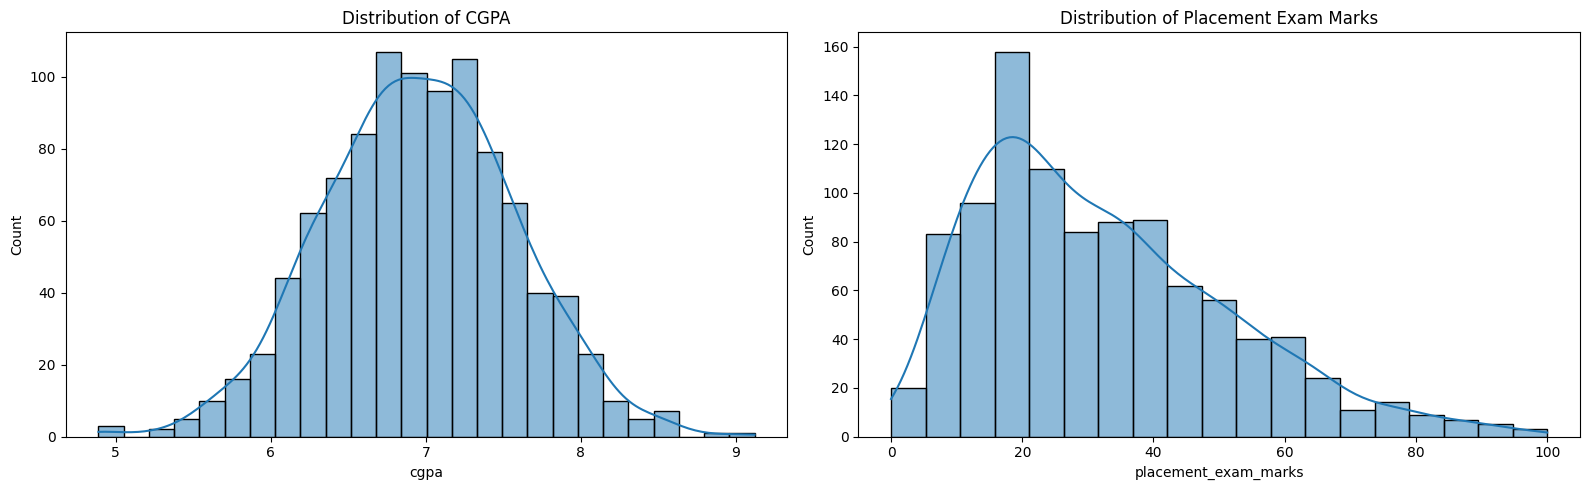

In [8]:

plt.figure(figsize=(16, 5))

# First subplot
plt.subplot(1, 2, 1)
sns.histplot(df['cgpa'], kde=True)
plt.title('Distribution of CGPA')

# Second subplot
plt.subplot(1, 2, 2)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Distribution of Placement Exam Marks')

plt.tight_layout()
plt.show()

In [10]:
print('Mean CGPA:', df['cgpa'].mean())
print('Standard Deviation of CGPA:', df['cgpa'].std())
print('Minimum CGPA:', df['cgpa'].min())
print('Maximum CGPA:', df['cgpa'].max())

Mean CGPA: 6.96124
Standard Deviation of CGPA: 0.6158978751323896
Minimum CGPA: 4.89
Maximum CGPA: 9.12


In [12]:
# finding min and max / boundary values for cgpa

print('Highest Allowed CGPA',df['cgpa'].mean()+3*df['cgpa'].std())
print('Lowest Allowed CGPA',df['cgpa'].mean()-3*df['cgpa'].std())

Highest Allowed CGPA 8.808933625397168
Lowest Allowed CGPA 5.113546374602832


In [15]:
# finding outliers in cgpa
print('Outlier CGPA values:')
df[(df['cgpa']>8.80) | (df['cgpa']<5.11)]

Outlier CGPA values:


,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


# Trimming 

In [16]:
new_df = df[(df['cgpa']<=8.80) & (df['cgpa']>=5.11)]

In [17]:
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [18]:
# Another Approach using z-score

# calculating z-score for cgpa
df['cgpa_zscore'] = (df['cgpa']-df['cgpa'].mean())/df['cgpa'].std()

In [19]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [22]:
# we have to only those students who have z-score between -3 to +3 as out of this range are considered as outliers

print('Outlier based on z-score:')
df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]

Outlier based on z-score:


,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [23]:
# removing outlier using trimming

new_df2 = df[(df['cgpa_zscore'] <= 3) & (df['cgpa_zscore'] >= -3)]

In [24]:
new_df2

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


# Capping 

In [25]:
upper_limit = df['cgpa'].mean()+3*df['cgpa'].std()
lower_limit = df['cgpa'].mean()-3*df['cgpa'].std()

In [26]:
upper_limit, lower_limit

(8.808933625397168, 5.113546374602832)

In [28]:
df['cgpa'] = np.where(df['cgpa']>upper_limit,upper_limit,
                      np.where(df['cgpa']<lower_limit,lower_limit,df['cgpa']
                                                                  )
                      )

In [30]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64

# Outlier Detection using Inter Quartile Range
It is applied on skewed data. (for normally distributed data use Z-Score) 

In [31]:
dfx = pd.read_csv('placement.csv')
dfx.sample(5)

,cgpa,placement_exam_marks,placed
248,6.90,44.0,0
477,5.78,18.0,0
145,7.08,28.0,0
695,6.75,11.0,1
223,6.15,11.0,1


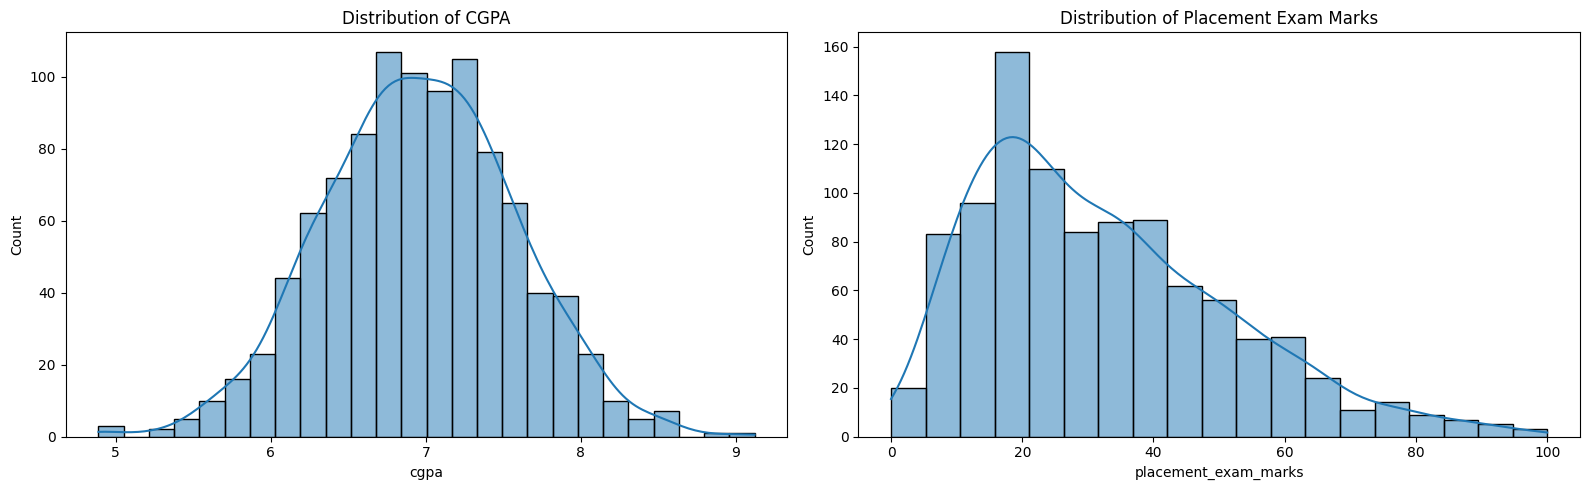

In [32]:

plt.figure(figsize=(16, 5))

# First subplot
plt.subplot(1, 2, 1)
sns.histplot(dfx['cgpa'], kde=True)
plt.title('Distribution of CGPA')

# Second subplot
plt.subplot(1, 2, 2)
sns.histplot(dfx['placement_exam_marks'], kde=True)
plt.title('Distribution of Placement Exam Marks')

plt.tight_layout()
plt.show()

In [33]:
# here we can cee that distribution of placement exam marks is skewed, so we can apply IQR method to remove outliers
dfx['placement_exam_marks'].skew()

0.8356419499466834

In [34]:
 dfx['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

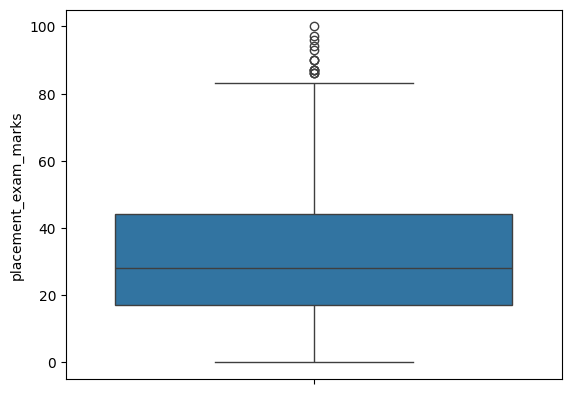

In [35]:
sns.boxplot(dfx['placement_exam_marks'])

In [36]:
# finding the IQR 

percentile25 = dfx['placement_exam_marks'].quantile(0.25)
percentile75 = dfx['placement_exam_marks'].quantile(0.75)


In [38]:
percentile25, percentile75

(17.0, 44.0)

In [39]:
iqr = percentile75 - percentile25

In [41]:
iqr

27.0

In [42]:
# upper limt = Q3 + 1.5*IQR
upper_limit = percentile75 + 1.5*iqr
# lower limit = Q1 - 1.5*IQR
lower_limit = percentile25 - 1.5*iqr


In [43]:
print('Upper Limit:', upper_limit)
print('Lower Limit:', lower_limit)

Upper Limit: 84.5
Lower Limit: -23.5


# Finding Outliers

In [45]:
dfx[dfx['placement_exam_marks']>upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [46]:
dfx[dfx['placement_exam_marks']<lower_limit]

,cgpa,placement_exam_marks,placed


# Trimmming

In [48]:
new_dfx = dfx[dfx['placement_exam_marks']<=upper_limit]

In [49]:
new_dfx.shape

(985, 3)

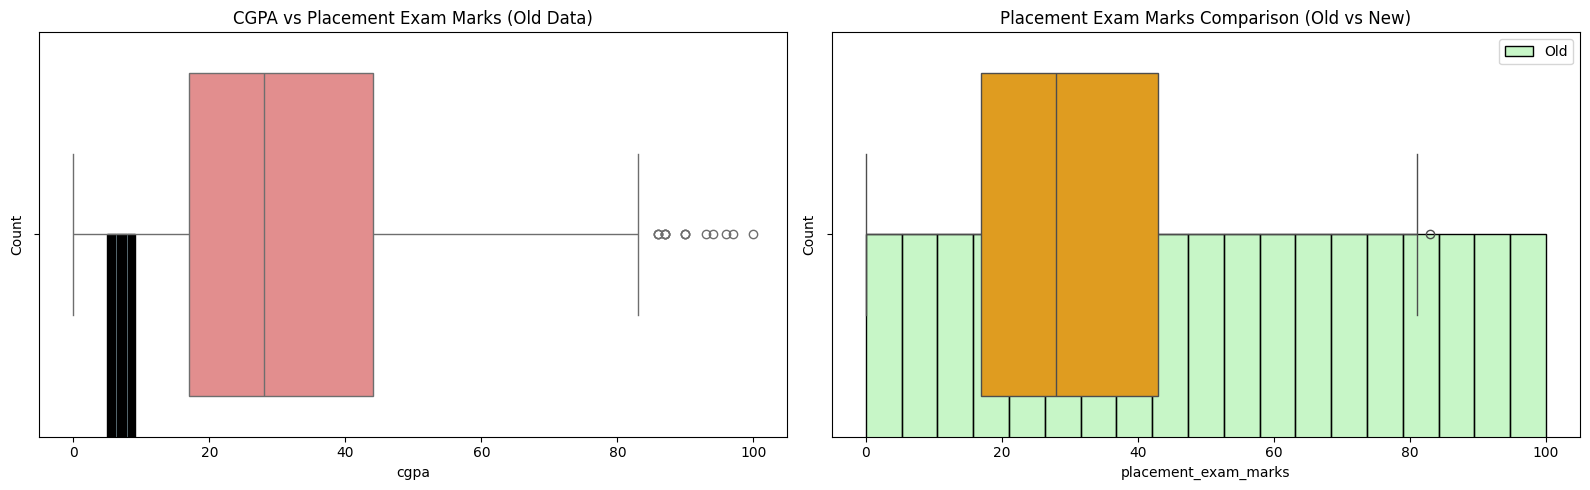

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left subplot ---
sns.histplot(dfx['cgpa'], kde=True, ax=axes[0], color='skyblue')
sns.boxplot(x=dfx['placement_exam_marks'], ax=axes[0], color='lightcoral')
axes[0].set_title('CGPA vs Placement Exam Marks (Old Data)')

# --- Right subplot ---
sns.histplot(dfx['placement_exam_marks'], kde=True, ax=axes[1], color='lightgreen', label='Old')
sns.boxplot(x=new_dfx['placement_exam_marks'], ax=axes[1], color='orange')
axes[1].set_title('Placement Exam Marks Comparison (Old vs New)')

plt.tight_layout()
plt.show()
